#INSTRUCTIONS:

🌟 Exercise 1: Understanding Data Visualization

Task: Explain why data visualization is important in data analysis.

Task: Describe the purpose of a line graph in data visualization.

🌟 Exercise 2: Creating a Line Plot for Temperature Variation

Objective: Create a simple line plot using Matplotlib that represents temperature variations over a week.

Tasks:
Use a list of temperature values for each day of the week (e.g., [72, 74, 76, 80, 82, 78, 75]).
Label the x-axis as “Day” and the y-axis as “Temperature (°F)”.
Add a title to the plot.
Display the plot.


🌟 Exercise 3: Visualizing Monthly Sales with a Bar Chart

Objective: Generate a bar chart using Matplotlib to visualize monthly sales data for a retail store.

Tasks:
Create a list of sales values for each month (e.g., [5000, 5500, 6200, 7000, 7500]).
Label the x-axis as “Month” and the y-axis as “Sales Amount ($)”.
Add a title to the bar chart.
Display the plot.

For exercises 4,5,6, you need to download this dataset:
Student Mental health


🌟 Exercise 4: Visualizing the Distribution of CGPA

Objective: Create a histogram to visualize the distribution of students’ CGPA.
Dataset Overview: Assume the CGPA data is categorized into ranges and loaded in a DataFrame named df.

Tasks:

Import necessary libraries.
Use Seaborn’s histplot to create a histogram of the CGPA categories.
Customize the histogram with a specific color and add a title.
Display the plot.


🌟 Exercise 5: Comparing Anxiety Levels Across Different Genders

Objective: Use a bar plot to compare the proportion of students experiencing anxiety across different genders.

Dataset Overview: The dataset includes columns: ‘Do you have Anxiety?’ and ‘Choose your gender’.

Tasks:

Import necessary libraries.
Use Seaborn to create a bar plot comparing anxiety levels across genders from the dataset df.
Customize the plot with an appropriate color palette and add a title.
Display the plot.


🌟 Exercise 6: Exploring the Relationship Between Age and Panic Attacks

Objective: Create a scatter plot to explore the relationship between students’ age and the occurrence of panic attacks.

Dataset Overview: The dataset includes columns: ‘Age’ and ‘Do you have Panic Attacks?’.

Tasks:

Import necessary libraries.
Convert panic attack responses to numeric values (e.g., Yes=1, No=0).
Use Seaborn’s scatterplot to create a scatter plot with ‘Age’ on the x-axis and numeric panic attack responses on the y-axis.
Customize the plot to improve readability by adding labels, a title, and adjusting point styles.
Display the plot.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    # Try reading the file with standard encoding first, fallback if needed
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')

    print("Dataset Shape:", df.shape)

    # 1. Data Scoping and Prep
    df.drop_duplicates(inplace=True)
    if 'Postal Code' in df.columns:
        df['Postal Code'] = df['Postal Code'].fillna(0)

    date_cols = ['Order Date', 'Ship Date']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=False)

    df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
    df['Order Year'] = df['Order Date'].dt.year
    df['Order Month'] = df['Order Date'].dt.month
    df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

    # Insights for Executive Summary
    total_sales = df['Sales'].sum()
    total_profit = df['Profit'].sum()
    profit_margin = (total_profit / total_sales) * 100
    state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)
    top_state = state_sales.index[-1]
    top_state_sales = state_sales.iloc[-1]
    top_5_percent = (state_sales.tail(5).sum()/total_sales)*100
    top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
    product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
    high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100

    print(f"\n--- EXECUTIVE METRICS ---")
    print(f"Total Sales: {total_sales}")
    print(f"Total Profit: {total_profit}")
    print(f"Margin: {profit_margin}")
    print(f"Top State: {top_state} ({top_state_sales})")
    print(f"Top 5 states %: {top_5_percent}")
    print(f"Top Category: {top_category}")
    print(f"High Discount Loss Rate: {high_discount_loss_rate}")

    # Generate Plot 1: Monthly Sales Trend (All)
    plt.figure(figsize=(10, 5))
    total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
    plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, marker='o', linewidth=2, markersize=4)
    plt.title('Monthly Sales Trend - All Categories', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Sales ($)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    with open('plot1.png', 'wb') as f:
        plt.savefig(f)
    plt.close()

    # Dashboard
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    ax1.plot(total_monthly.index.to_timestamp(), total_monthly.values, marker='o')
    ax1.set_title('Monthly Sales Trend')
    ax1.tick_params(axis='x', rotation=45)

    category_sales = df.groupby('Category')['Sales'].sum()
    ax2.bar(category_sales.index, category_sales.values)
    ax2.set_title('Sales by Category')

    top_10_states = state_sales.tail(10)
    ax3.barh(range(len(top_10_states)), top_10_states.values)
    ax3.set_yticks(range(len(top_10_states)))
    ax3.set_yticklabels(top_10_states.index)
    ax3.set_title('Top 10 States by Sales')

    for category in df['Category'].unique():
        cat_data = df[df['Category'] == category]
        ax4.scatter(cat_data['Discount'], cat_data['Profit'], label=category, alpha=0.6)
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax4.set_title('Discount vs Profit by Category')
    ax4.legend()
    plt.tight_layout()
    with open('dashboard.png', 'wb') as f:
        plt.savefig(f)
    plt.close()

    print("\nCharts generated successfully.")
except Exception as e:
    print(f"Error: {e}")

Dataset Shape: (9994, 21)

--- EXECUTIVE METRICS ---
Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Margin: 12.467217240315604
Top State: California (457687.6315)
Top 5 states %: 51.97216982341211
Top Category: Technology
High Discount Loss Rate: 96.76956209619526

Charts generated successfully.


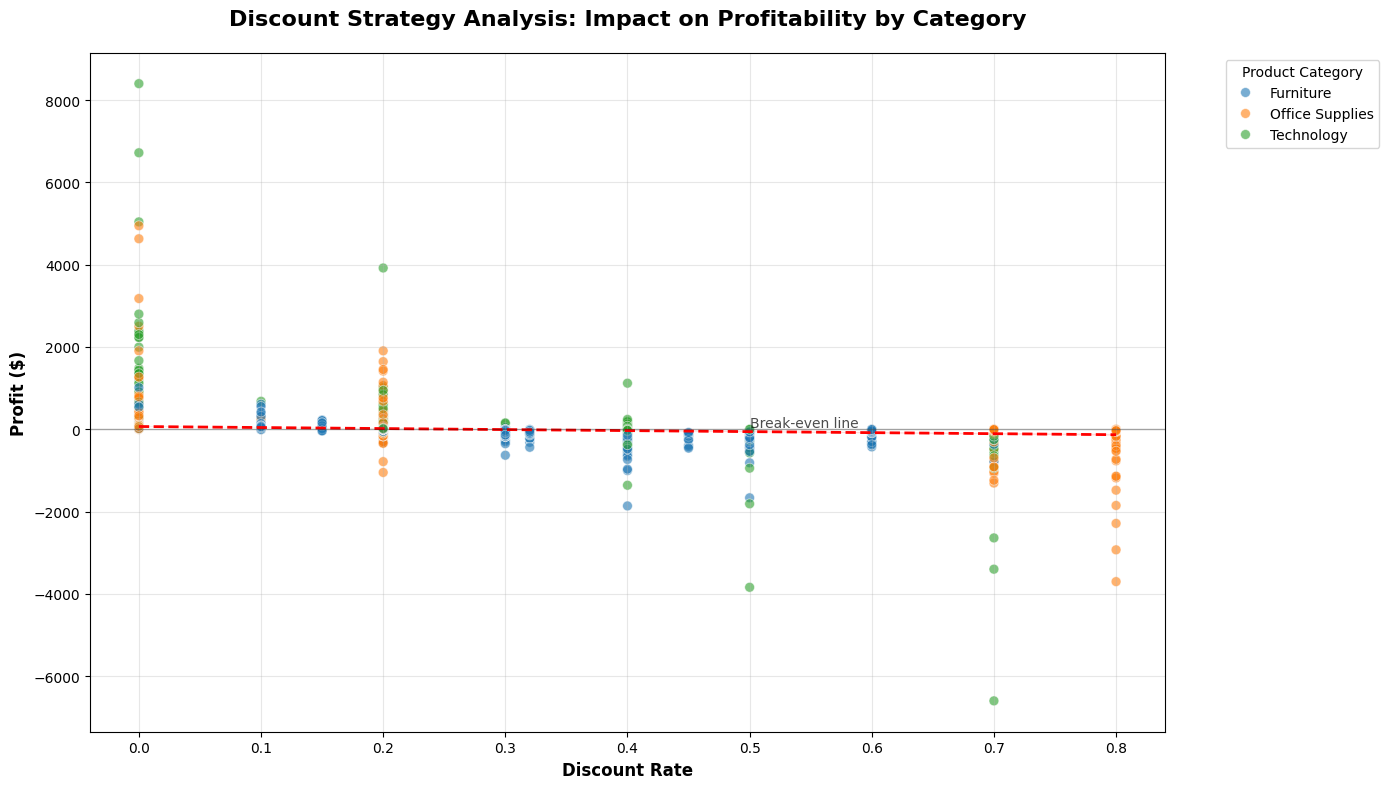

In [2]:
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

plt.title('Discount Strategy Analysis: Impact on Profitability by Category', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    df = pd.read_csv("Student Mental health.csv")
    print(df.columns.tolist())
    print(df.head(2))
except Exception as e:
    print(f"Error loading: {e}")

['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']
        Timestamp Choose your gender   Age What is your course?  \
0  8/7/2020 12:02             Female  18.0          Engineering   
1  8/7/2020 12:04               Male  21.0    Islamic education   

  Your current year of Study What is your CGPA? Marital status  \
0                     year 1        3.00 - 3.49             No   
1                     year 2        3.00 - 3.49             No   

  Do you have Depression? Do you have Anxiety? Do you have Panic attack?  \
0                     Yes                   No                       Yes   
1                      No                  Yes                        No   

  Did you seek any specialist for a treatment?  
0                                           No  
1      

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Student Mental health.csv")

# Clean up column names and string values just in case
df.columns = df.columns.str.strip()
if 'What is your CGPA?' in df.columns:
    df['What is your CGPA?'] = df['What is your CGPA?'].str.strip()

# --- Exercise 4: Histogram of CGPA ---
plt.figure(figsize=(10, 6))
# Sort the categories to make the histogram look logical
cgpa_order = sorted(df['What is your CGPA?'].dropna().unique())
sns.histplot(data=df, x='What is your CGPA?', color='teal', shrink=.8)
plt.title('Distribution of Students\' CGPA', fontsize=14, fontweight='bold')
plt.xlabel('CGPA Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('ex4.png')
plt.close()

# --- Exercise 5: Bar plot comparing Anxiety levels across genders ---
plt.figure(figsize=(8, 6))
# To show proportion, map Yes to 1 and No to 0
df['Anxiety_Numeric'] = df['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})
sns.barplot(data=df, x='Choose your gender', y='Anxiety_Numeric', palette='Set2')
plt.title('Proportion of Students Experiencing Anxiety by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Proportion with Anxiety')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('ex5.png')
plt.close()

# --- Exercise 6: Scatter plot for Age and Panic Attacks ---
plt.figure(figsize=(10, 6))
df['Panic_Numeric'] = df['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})
sns.scatterplot(data=df, x='Age', y='Panic_Numeric', alpha=0.6, s=100, color='crimson')
plt.title('Relationship Between Age and Panic Attacks', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Panic Attack (1 = Yes, 0 = No)')
plt.yticks([0, 1], ['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.savefig('ex6.png')
plt.close()

print("Plots generated successfully.")

Plots generated successfully.


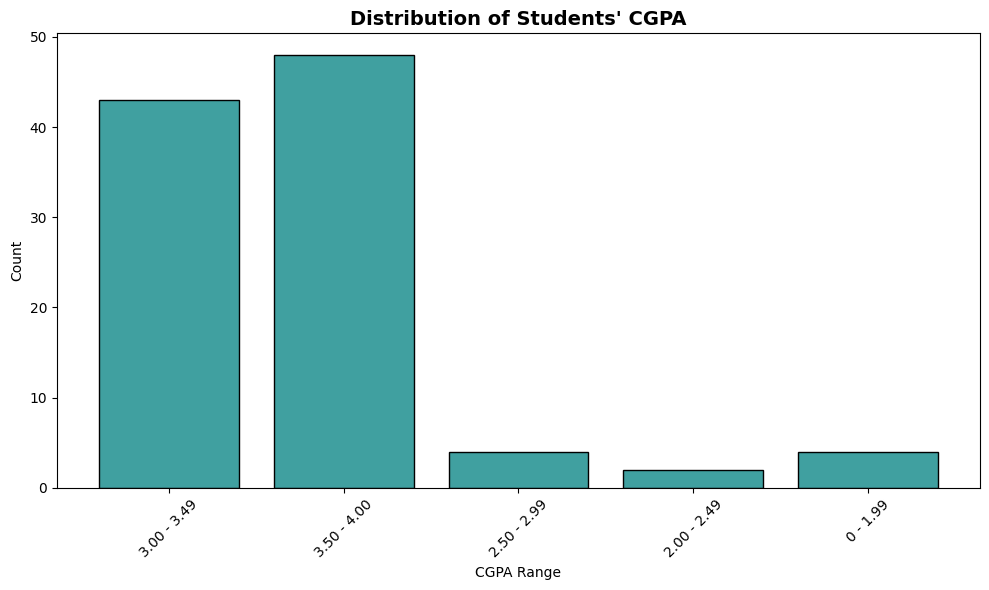

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and clean column/values
df = pd.read_csv("Student Mental health.csv")
df.columns = df.columns.str.strip()
df['What is your CGPA?'] = df['What is your CGPA?'].str.strip()

# Create histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='What is your CGPA?', color='teal', shrink=.8)

# Customize plot
plt.title('Distribution of Students\' CGPA', fontsize=14, fontweight='bold')
plt.xlabel('CGPA Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

# Display plot
plt.show()

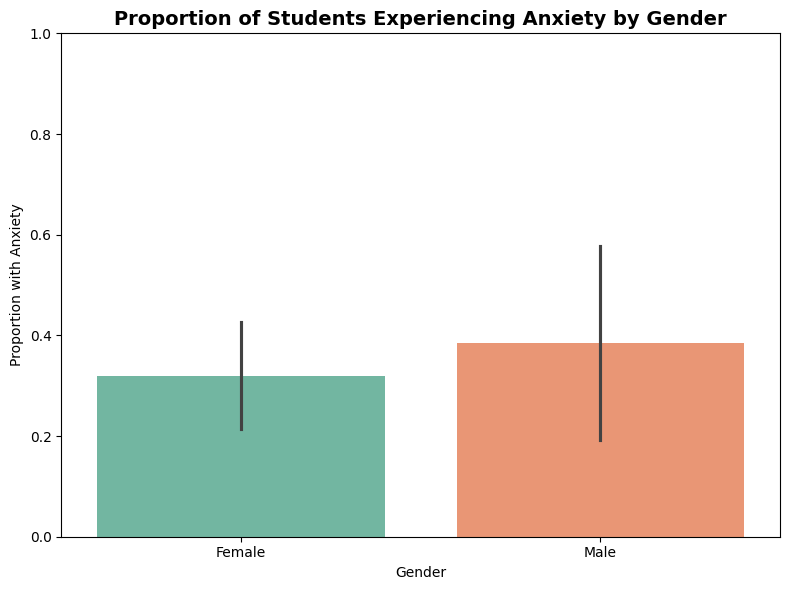

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Student Mental health.csv")
df.columns = df.columns.str.strip()

# Convert Anxiety responses to numeric values to calculate proportions
df['Anxiety_Numeric'] = df['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})

# Create bar plot
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Choose your gender', y='Anxiety_Numeric', palette='Set2')

# Customize plot
plt.title('Proportion of Students Experiencing Anxiety by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Proportion with Anxiety')
plt.ylim(0, 1) # Set y-axis to represent 0% to 100%
plt.tight_layout()

# Display plot
plt.show()

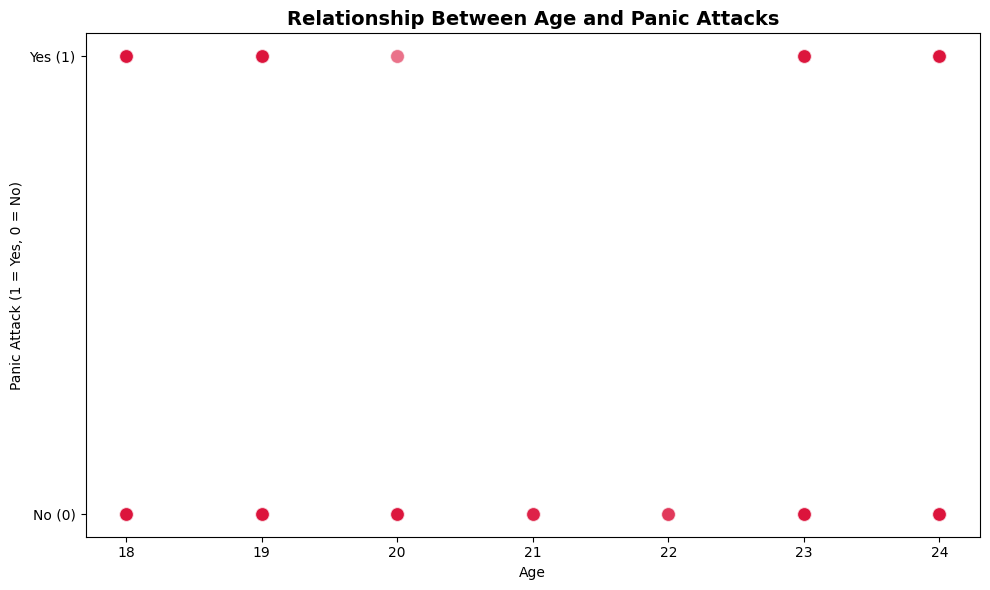

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Student Mental health.csv")
df.columns = df.columns.str.strip()

# Convert panic attack responses to numeric values (Yes=1, No=0)
df['Panic_Numeric'] = df['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Panic_Numeric', alpha=0.6, s=100, color='crimson')

# Customize plot
plt.title('Relationship Between Age and Panic Attacks', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Panic Attack (1 = Yes, 0 = No)')
plt.yticks([0, 1], ['No (0)', 'Yes (1)'])
plt.tight_layout()

# Display plot
plt.show()